# LOSO Cross-Validation K-means Notebook

This notebook implements **Leave-One-Subject-Out (LOSO) cross-validation**


To answer the research question: does the best model generalize to unseen participants?



In [1]:
from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from typing import Optional

warnings.filterwarnings("ignore")
# Resolve repository root and ensure src is importable from this notebook.
cwd = Path.cwd()
if (cwd / "src").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate repository root containing src/")

src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

REPO_ROOT


PosixPath('/Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2')

## Settings

1. A. Main PCA run

- USE_PCA = True
- PCA_VARIANCE_THRESHOLD = 0.80
- FIXED_K = 3


2. B. No-PCA comparison

- USE_PCA = False
- FIXED_K = 3


In [3]:
# =========================
# LOSO SETTINGS
# =========================

from pathlib import Path

DATA_PATH = REPO_ROOT.parent / "data" / "HR_data_2.csv"

PHYSIOLOGICAL_PREFIXES = ("HR_", "EDA_", "TEMP_")
GROUP_COLUMN = "Individual"
PHASE_COLUMN = "Phase"

# Representation choice
USE_PCA = False              # True = PCA latent space, False = all 51 features
PCA_VARIANCE_THRESHOLD = 0.80

# K-means choice
FIXED_K = 3                 # main chosen model
KMEANS_N_INIT = 50
RANDOM_STATE = 42

# -------------------------
# Build output folder name
# -------------------------
if USE_PCA:
    rep_tag = f"pca_{PCA_VARIANCE_THRESHOLD:.1f}"
else:
    rep_tag = "no_pca"

run_name = f"k{FIXED_K}"

OUTPUT_DIR = REPO_ROOT / f"outputs_loso_kmeans_{rep_tag}" / run_name

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "results").mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("Exists?   ", DATA_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Representation:", rep_tag)
print("Run type:", run_name)

DATA_PATH: /Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/data/HR_data_2.csv
Exists?    True
OUTPUT_DIR: /Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2/outputs_loso_kmeans_no_pca/k3
Representation: no_pca
Run type: k3


In [4]:
# =========================
# Load dataset and select physiological features
# =========================

df = pd.read_csv(DATA_PATH)

feature_cols = [
    c for c in df.columns
    if c.startswith(PHYSIOLOGICAL_PREFIXES)
]

required_cols = [GROUP_COLUMN, PHASE_COLUMN]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if len(feature_cols) == 0:
    raise ValueError("No physiological feature columns found.")

print("Dataset shape:", df.shape)
print("Number of physiological feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])

print("\nPhase counts:")
print(df[PHASE_COLUMN].value_counts(dropna=False))

print("\nGroup count (Individuals):", df[GROUP_COLUMN].nunique())


Dataset shape: (312, 71)
Number of physiological feature columns: 51
First 10 feature columns: ['HR_TD_Mean', 'HR_TD_Median', 'HR_TD_std', 'HR_TD_Min', 'HR_TD_Max', 'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew', 'HR_TD_Slope_min', 'HR_TD_Slope_max']

Phase counts:
Phase
phase3    104
phase2    104
phase1    104
Name: count, dtype: int64

Group count (Individuals): 26


In [5]:
# =========================
# Helper functions
# =========================

def zscore_within_groups(frame: pd.DataFrame, feature_columns: list[str], group_column: str) -> pd.DataFrame:
    """Within-group z-score normalization."""
    out = frame.copy()

    def _zscore(series: pd.Series) -> pd.Series:
        std = series.std(ddof=0)
        if pd.isna(std) or std == 0:
            return pd.Series(np.zeros(len(series)), index=series.index)
        return (series - series.mean()) / std

    out[feature_columns] = (
        out.groupby(group_column)[feature_columns]
           .transform(_zscore)
    )
    return out


def fit_pca_train_transform_test(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    variance_threshold: float,
    random_state: int = 42,
):
    """Fit PCA on train only, then transform train and test."""
    pca_full = PCA(random_state=random_state)
    Z_train_full = pca_full.fit_transform(X_train)
    Z_test_full = pca_full.transform(X_test)

    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = int(np.searchsorted(cumvar, variance_threshold) + 1)

    Z_train = Z_train_full[:, :n_components]
    Z_test = Z_test_full[:, :n_components]

    variance_table = pd.DataFrame({
        "component": np.arange(1, len(cumvar) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": cumvar,
    })

    return pca_full, Z_train, Z_test, n_components, variance_table


def fit_predict_kmeans(
    Z_train: np.ndarray,
    Z_test: np.ndarray,
    k: int,
    random_state: int,
    n_init: int,
):
    """Fit K-means on train and predict labels for train/test."""
    km = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=n_init,
    )
    km.fit(Z_train)
    train_labels = km.labels_
    test_labels = km.predict(Z_test)
    return km, train_labels, test_labels


def fit_fold(train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
    """Run one LOSO fold without leakage."""
    # 1) Within-subject normalization inside fold
    train_norm = zscore_within_groups(train_df, feature_cols, GROUP_COLUMN)
    test_norm = zscore_within_groups(test_df, feature_cols, GROUP_COLUMN)

    # 2) Fit imputer on training fold only
    imputer = SimpleImputer(strategy="median")
    X_train = pd.DataFrame(
        imputer.fit_transform(train_norm[feature_cols]),
        columns=feature_cols,
        index=train_norm.index,
    )
    X_test = pd.DataFrame(
        imputer.transform(test_norm[feature_cols]),
        columns=feature_cols,
        index=test_norm.index,
    )

    # 3) Representation: PCA or no PCA
    if USE_PCA:
        pca, Z_train, Z_test, n_components, variance_table = fit_pca_train_transform_test(
            X_train=X_train,
            X_test=X_test,
            variance_threshold=PCA_VARIANCE_THRESHOLD,
            random_state=RANDOM_STATE,
        )
    else:
        Z_train = X_train.to_numpy()
        Z_test = X_test.to_numpy()
        n_components = X_train.shape[1]
        variance_table = None

    # 4) Fit final K-means on training fold only
    km, train_labels, test_labels = fit_predict_kmeans(
        Z_train=Z_train,
        Z_test=Z_test,
        k=FIXED_K,
        random_state=RANDOM_STATE,
        n_init=KMEANS_N_INIT,
    )

    # 5) External evaluation on the held-out subject only
    y_test = test_df[PHASE_COLUMN].to_numpy()
    nmi = normalized_mutual_info_score(y_test, test_labels)
    ari = adjusted_rand_score(y_test, test_labels)

    return {
        "final_k": FIXED_K,
        "n_components": n_components,
        "nmi": nmi,
        "ari": ari,
        "test_labels": test_labels,
        "test_phases": y_test,
        "test_index": test_df.index.to_numpy(),
        "variance_table": variance_table,
    }

## Run LOSO CV

This loop leaves out one `Individual` at a time.

For each fold:
1. normalize within subject
2. fit imputer on train only
3. fit PCA on train only
4. choose `k` on train only (or use fixed `k`)
5. fit GMM on train only
6. evaluate on the held-out subject


In [6]:
# =========================
# LOSO CV
# =========================

logo = LeaveOneGroupOut()
groups = df[GROUP_COLUMN]

fold_rows = []
all_test_predictions = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(df, groups=groups), start=1):
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    held_out_group = test_df[GROUP_COLUMN].iloc[0]
    result = fit_fold(train_df, test_df)

    fold_rows.append({
        "fold": fold_idx,
        "held_out_individual": held_out_group,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "selected_k": result["final_k"],
        "selected_pca_components": result["n_components"],
        "test_nmi": result["nmi"],
        "test_ari": result["ari"],
    })

    pred_df = pd.DataFrame({
        "index": result["test_index"],
        "fold": fold_idx,
        "held_out_individual": held_out_group,
        "true_phase": result["test_phases"],
        "predicted_cluster": result["test_labels"],
    })
    all_test_predictions.append(pred_df)

fold_results = pd.DataFrame(fold_rows)
test_predictions = pd.concat(all_test_predictions, ignore_index=True)

print("LOSO completed.")
print("\nFold-level results:")
display(fold_results.head())

print("\nSummary:")
display(fold_results[["test_nmi", "test_ari", "selected_k", "selected_pca_components"]].agg(["mean", "std", "min", "max"]))

LOSO completed.

Fold-level results:


,fold,held_out_individual,n_train,n_test,selected_k,selected_pca_components,test_nmi,test_ari
0,1,1,300,12,3,51,0.567023,0.421053
1,2,2,300,12,3,51,0.393364,0.136519
2,3,3,300,12,3,51,0.288434,0.092409
3,4,4,300,12,3,51,0.384324,0.142857
4,5,5,300,12,3,51,0.452495,0.285714



Summary:


,test_nmi,test_ari,selected_k,selected_pca_components
mean,0.284178,0.076742,3.0,51.0
std,0.148304,0.148934,0.0,0.0
min,0.034773,-0.163823,3.0,51.0
max,0.567023,0.421053,3.0,51.0


In [7]:
# =========================
# Save fold results
# =========================

results_dir = OUTPUT_DIR / "results"
figures_dir = OUTPUT_DIR / "figures"

fold_results.to_csv(results_dir / "loso_fold_results.csv", index=False)
test_predictions.to_csv(results_dir / "loso_test_predictions.csv", index=False)

summary = {
    "n_folds": int(len(fold_results)),
    "cv_scheme": "LeaveOneGroupOut",
    "group_column": GROUP_COLUMN,
    "phase_column": PHASE_COLUMN,
    "representation": "pca" if USE_PCA else "no_pca",
    "pca_variance_threshold": float(PCA_VARIANCE_THRESHOLD) if USE_PCA else None,
    "fixed_k": int(FIXED_K),
    "kmeans_n_init": int(KMEANS_N_INIT),
    "mean_test_nmi": float(fold_results["test_nmi"].mean()),
    "std_test_nmi": float(fold_results["test_nmi"].std(ddof=1)),
    "mean_test_ari": float(fold_results["test_ari"].mean()),
    "std_test_ari": float(fold_results["test_ari"].std(ddof=1)),
    "mean_selected_k": float(fold_results["selected_k"].mean()),
    "selected_k_counts": fold_results["selected_k"].value_counts().sort_index().to_dict(),
    "mean_selected_pca_components": float(fold_results["selected_pca_components"].mean()),
}

with (results_dir / "loso_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

summary

{'n_folds': 26,
 'cv_scheme': 'LeaveOneGroupOut',
 'group_column': 'Individual',
 'phase_column': 'Phase',
 'representation': 'no_pca',
 'pca_variance_threshold': None,
 'fixed_k': 3,
 'kmeans_n_init': 50,
 'mean_test_nmi': 0.2841782580334042,
 'std_test_nmi': 0.14830396419829242,
 'mean_test_ari': 0.076741542779232,
 'std_test_ari': 0.148934224255029,
 'mean_selected_k': 3.0,
 'selected_k_counts': {3: 26},
 'mean_selected_pca_components': 51.0}

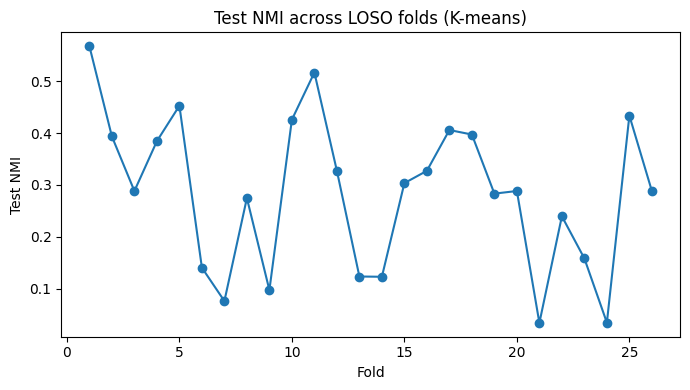

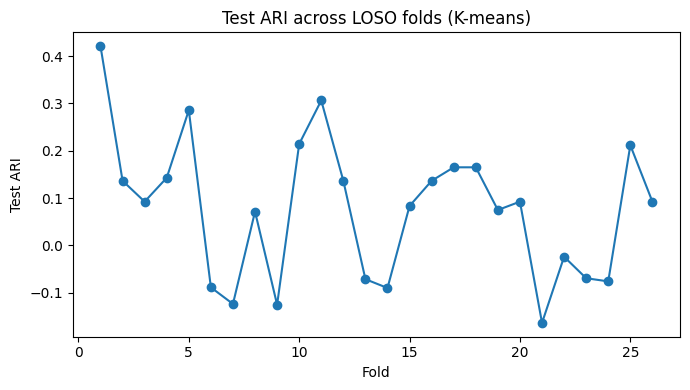

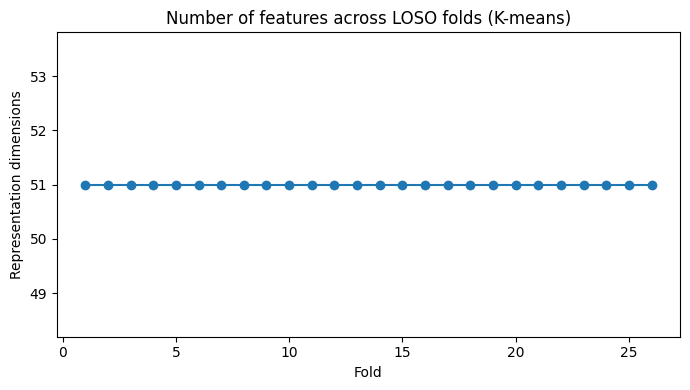

In [8]:
# =========================
# Diagnostic plots
# =========================

# 1) NMI across folds
plt.figure(figsize=(7, 4))
plt.plot(fold_results["fold"], fold_results["test_nmi"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Test NMI")
plt.title("Test NMI across LOSO folds (K-means)")
plt.tight_layout()
plt.savefig(figures_dir / "loso_test_nmi_by_fold.png", dpi=200)
plt.show()

# 2) ARI across folds
plt.figure(figsize=(7, 4))
plt.plot(fold_results["fold"], fold_results["test_ari"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Test ARI")
plt.title("Test ARI across LOSO folds (K-means)")
plt.tight_layout()
plt.savefig(figures_dir / "loso_test_ari_by_fold.png", dpi=200)
plt.show()

# 3) Components across folds
plt.figure(figsize=(7, 4))
plt.plot(fold_results["fold"], fold_results["selected_pca_components"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Representation dimensions")
title_suffix = "PCA components" if USE_PCA else "Number of features"
plt.title(f"{title_suffix} across LOSO folds (K-means)")
plt.tight_layout()
plt.savefig(figures_dir / "loso_representation_dims_by_fold.png", dpi=200)
plt.show()

### Result 
